# DSP501 phased experiment notebook

Run each numbered section independently. A run is an experiment checkpoint (`run-N`), never a configuration version.

## 00 Config / Run allocation

In [1]:
from __future__ import annotations
import json
from pathlib import Path
from IPython.display import Image, display
from src.orchestration import execute_phase, find_project_root, open_run

RUN_ID = None  # None allocates the next run; an integer resumes that incomplete run.
WORKERS = 0
ROOT = find_project_root(Path.cwd())
CONFIG_PATH = ROOT / 'configs/config.json'
context = open_run(CONFIG_PATH, RUN_ID, project_root=ROOT)
config = context.config
manifest = json.loads(config.manifest_path.read_text())
display({'run': config.run_tag, 'directory': str(config.run_dir), 'status': manifest['status'], 'phases': manifest['phases']})

{'run': 'run-1',
 'directory': 'outputs/dsp501-frozen-cnn-factorial/runs/run-1',
 'status': 'running',
 'phases': {'prepare': {'status': 'pending',
   'attempts': 0,
   'started_at': None,
   'completed_at': None,
   'error': None,
   'outputs': []},
  'eda': {'status': 'pending',
   'attempts': 0,
   'started_at': None,
   'completed_at': None,
   'error': None,
   'outputs': []},
  'train': {'status': 'pending',
   'attempts': 0,
   'started_at': None,
   'completed_at': None,
   'error': None,
   'outputs': []},
  'evaluate_raw': {'status': 'pending',
   'attempts': 0,
   'started_at': None,
   'completed_at': None,
   'error': None,
   'outputs': []},
  'evaluate_dsp': {'status': 'pending',
   'attempts': 0,
   'started_at': None,
   'completed_at': None,
   'error': None,
   'outputs': []},
  'signal_analysis': {'status': 'pending',
   'attempts': 0,
   'started_at': None,
   'completed_at': None,
   'error': None,
   'outputs': []},
  'statistics': {'status': 'pending',
   'attem

## 01 Dataset preparation

In [2]:
prepare = execute_phase(context, 'prepare', workers=WORKERS)
inventory = prepare.data['inventory']
display(inventory)

  train: 60 speakers, 8400 clips
  validation: 20 speakers, 1000 clips
  test: 29 speakers, 1450 clips
  seen_test: 60 speakers, 1800 clips


{'vctk_wav48': 'dataset/VCTK-Corpus-0.80/wav48',
 'vctk_speakers': 109,
 'vctk_speaker_ids': ['p225',
  'p226',
  'p227',
  'p228',
  'p229',
  'p230',
  'p231',
  'p232',
  'p233',
  'p234',
  'p236',
  'p237',
  'p238',
  'p239',
  'p240',
  'p241',
  'p243',
  'p244',
  'p245',
  'p246',
  'p247',
  'p248',
  'p249',
  'p250',
  'p251',
  'p252',
  'p253',
  'p254',
  'p255',
  'p256',
  'p257',
  'p258',
  'p259',
  'p260',
  'p261',
  'p262',
  'p263',
  'p264',
  'p265',
  'p266',
  'p267',
  'p268',
  'p269',
  'p270',
  'p271',
  'p272',
  'p273',
  'p274',
  'p275',
  'p276',
  'p277',
  'p278',
  'p279',
  'p280',
  'p281',
  'p282',
  'p283',
  'p284',
  'p285',
  'p286',
  'p287',
  'p288',
  'p292',
  'p293',
  'p294',
  'p295',
  'p297',
  'p298',
  'p299',
  'p300',
  'p301',
  'p302',
  'p303',
  'p304',
  'p305',
  'p306',
  'p307',
  'p308',
  'p310',
  'p311',
  'p312',
  'p313',
  'p314',
  'p315',
  'p316',
  'p317',
  'p318',
  'p323',
  'p326',
  'p329',
  'p330'

## 02 EDA

{'selected_edges_hz': {'low': 31.25, 'high': 3500.0},
 'retained_energy_pct': {'speech': 98.45877080323362,
  'noise': 89.82986983596675}}

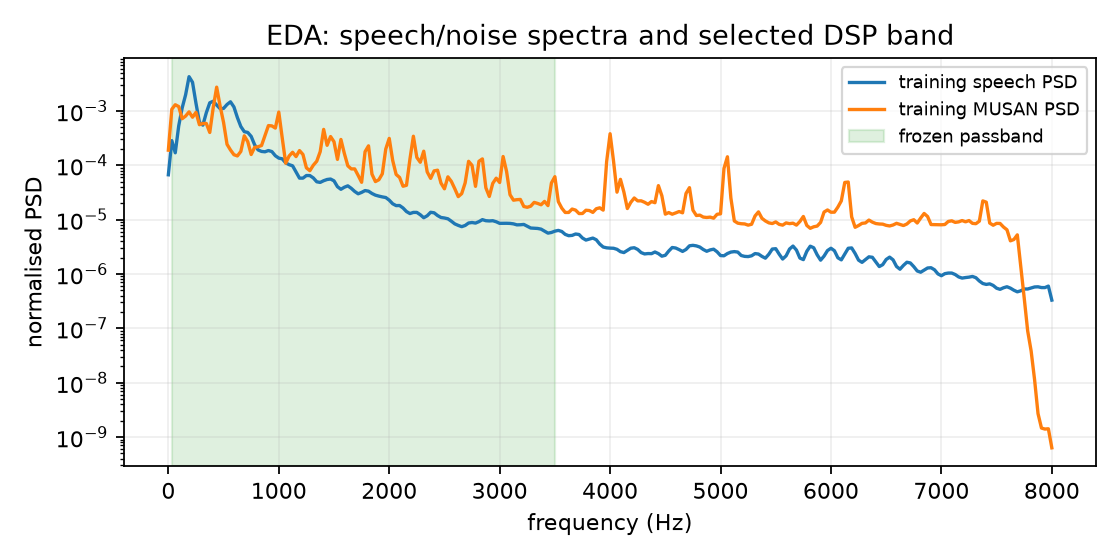

In [3]:
eda = execute_phase(context, 'eda', workers=WORKERS)
design = eda.data['design']
display({'selected_edges_hz': design['selected_edges_hz'], 'retained_energy_pct': design['retained_energy_pct']})
display(Image(filename=eda.data['figure']))

## 03 Train robust CNN

[{'seed': 11,
  'checkpoint_path': 'outputs/dsp501-frozen-cnn-factorial/runs/run-1/seed-11/robust_cnn/encoder.pt',
  'best_validation_accuracy': 0.885,
  'best_epoch': 13,
  'epochs_run': 18,
  'n_train_speakers': 60,
  'n_parameters': 1993824},
 {'seed': 22,
  'checkpoint_path': 'outputs/dsp501-frozen-cnn-factorial/runs/run-1/seed-22/robust_cnn/encoder.pt',
  'best_validation_accuracy': 0.8775,
  'best_epoch': 16,
  'epochs_run': 18,
  'n_train_speakers': 60,
  'n_parameters': 1993824},
 {'seed': 33,
  'checkpoint_path': 'outputs/dsp501-frozen-cnn-factorial/runs/run-1/seed-33/robust_cnn/encoder.pt',
  'best_validation_accuracy': 0.88375,
  'best_epoch': 17,
  'epochs_run': 18,
  'n_train_speakers': 60,
  'n_parameters': 1993824}]

['outputs/dsp501-frozen-cnn-factorial/runs/run-1/seed-11/robust_cnn/encoder.pt',
 'outputs/dsp501-frozen-cnn-factorial/runs/run-1/seed-22/robust_cnn/encoder.pt',
 'outputs/dsp501-frozen-cnn-factorial/runs/run-1/seed-33/robust_cnn/encoder.pt']

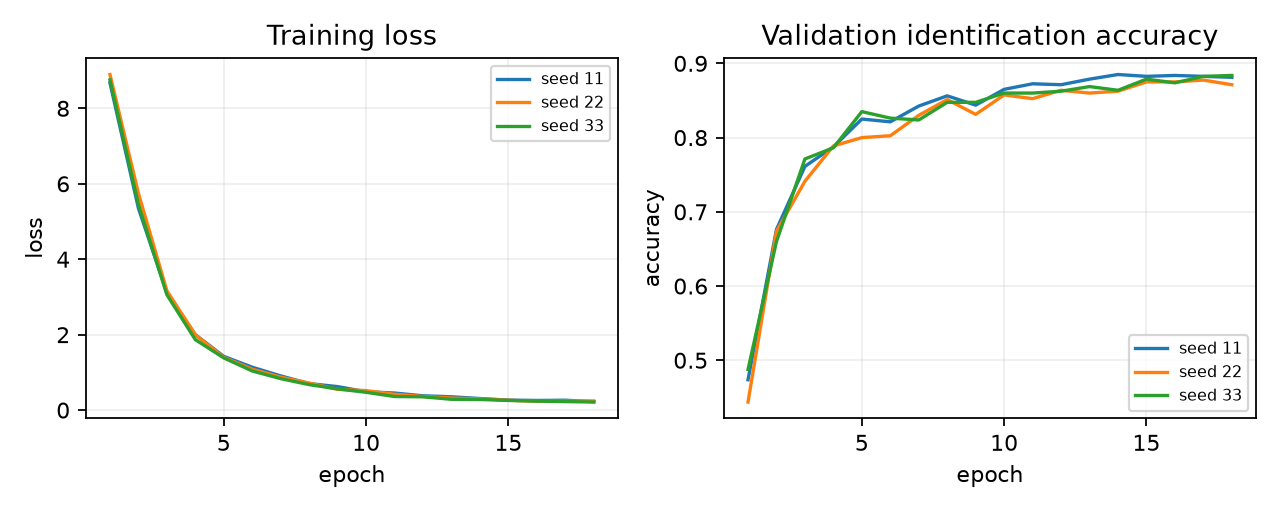

In [4]:
training = execute_phase(context, 'train', workers=WORKERS)
display(training.data['training'])
display(training.data['checkpoints'])
for path in training.data['figures']:
    display(Image(filename=path))

## 04 Evaluate raw

In [5]:
raw = execute_phase(context, 'evaluate_raw', workers=WORKERS)
display({'reports_written': len(raw.data['reports']), 'cells': ['raw']})

  seed 11 unseen clean             raw              acc 0.9017
  seed 11 unseen noise-snr-0       raw              acc 0.6362
  seed 11 unseen noise-snr-5       raw              acc 0.7552
  seed 11 unseen noise-snr-10      raw              acc 0.8112
  seed 11 unseen noise-snr-15      raw              acc 0.8431
  seed 11 unseen noise-snr-20      raw              acc 0.8698
  seed 11 unseen music-snr-0       raw              acc 0.5983
  seed 11 unseen music-snr-5       raw              acc 0.7440
  seed 11 unseen music-snr-10      raw              acc 0.8250
  seed 11 unseen music-snr-15      raw              acc 0.8629
  seed 11 unseen music-snr-20      raw              acc 0.8836
  seed 11 unseen speech-snr-0      raw              acc 0.6155
  seed 11 unseen speech-snr-5      raw              acc 0.7716
  seed 11 unseen speech-snr-10     raw              acc 0.8466
  seed 11 unseen speech-snr-15     raw              acc 0.8759
  seed 11 unseen speech-snr-20     raw              acc

{'reports_written': 126, 'cells': ['raw']}

## 05 Evaluate DSP front-ends

In [6]:
dsp = execute_phase(context, 'evaluate_dsp', workers=WORKERS)
display({'reports_written': len(dsp.data['reports']), 'cells': ['bandpass', 'wiener', 'bandpass_wiener']})

  seed 11 unseen clean             bandpass         acc 0.8552
  seed 11 unseen clean             wiener           acc 0.8888
  seed 11 unseen clean             bandpass_wiener  acc 0.8310
  seed 11 unseen noise-snr-0       bandpass         acc 0.5405
  seed 11 unseen noise-snr-0       wiener           acc 0.5776
  seed 11 unseen noise-snr-0       bandpass_wiener  acc 0.4776
  seed 11 unseen noise-snr-5       bandpass         acc 0.6819
  seed 11 unseen noise-snr-5       wiener           acc 0.6914
  seed 11 unseen noise-snr-5       bandpass_wiener  acc 0.5974
  seed 11 unseen noise-snr-10      bandpass         acc 0.7491
  seed 11 unseen noise-snr-10      wiener           acc 0.7733
  seed 11 unseen noise-snr-10      bandpass_wiener  acc 0.6897
  seed 11 unseen noise-snr-15      bandpass         acc 0.7888
  seed 11 unseen noise-snr-15      wiener           acc 0.8207
  seed 11 unseen noise-snr-15      bandpass_wiener  acc 0.7388
  seed 11 unseen noise-snr-20      bandpass         acc

{'reports_written': 378, 'cells': ['bandpass', 'wiener', 'bandpass_wiener']}

## 06 Signal-level analysis

In [7]:
signal_analysis = execute_phase(context, 'signal_analysis', workers=WORKERS)
display(signal_analysis.data['positive_control'])
display(signal_analysis.data['characterisation'])

{'purpose': 'technical DSP-positive control; not recognition evidence',
 'measurements': [{'input_snr_db': 0.0,
   'before_snr_db': 0.0,
   'after_snr_db': 14.827922821044922,
   'snr_gain_db': 14.827922821044922},
  {'input_snr_db': 5.0,
   'before_snr_db': 4.999999523162842,
   'after_snr_db': 18.7910213470459,
   'snr_gain_db': 13.791021823883057}]}

{'n_clips': 100,
 'measurements': [{'cell': 'raw',
   'family': 'noise',
   'input_snr_db': 0.0,
   'output_snr_db': -5.9537768493100884e-08,
   'snr_gain_db': 0.0},
  {'cell': 'bandpass',
   'family': 'noise',
   'input_snr_db': 0.0,
   'output_snr_db': 1.443078483552672,
   'snr_gain_db': 1.4430785430904405},
  {'cell': 'wiener',
   'family': 'noise',
   'input_snr_db': 0.0,
   'output_snr_db': 2.843763437901391,
   'snr_gain_db': 2.8437634974391597},
  {'cell': 'bandpass_wiener',
   'family': 'noise',
   'input_snr_db': 0.0,
   'output_snr_db': 3.7387451762426647,
   'snr_gain_db': 3.738745235780433},
  {'cell': 'raw',
   'family': 'noise',
   'input_snr_db': 5.0,
   'output_snr_db': 4.999999804496765,
   'snr_gain_db': 0.0},
  {'cell': 'bandpass',
   'family': 'noise',
   'input_snr_db': 5.0,
   'output_snr_db': 5.8461136800050735,
   'snr_gain_db': 0.8461138755083084},
  {'cell': 'wiener',
   'family': 'noise',
   'input_snr_db': 5.0,
   'output_snr_db': 7.477697067260742,
   'snr

## 07 Statistical analysis

In [8]:
statistics = execute_phase(context, 'statistics', workers=WORKERS)
display(statistics.data['factorial'])

{'seen': {'accuracy': {'bandpass_main': {'n_speakers': 60,
    'n_paired_speaker_strata': 3780,
    'mean_delta': -0.050873015873015875,
    'ci_low': -0.059302248677248676,
    'ci_high': -0.04252529761904762,
    'bootstrap_replicates': 2000,
    'resampling_unit': 'test speaker; all seed, SNR, family, and query observations retained'},
   'wiener_main': {'n_speakers': 60,
    'n_paired_speaker_strata': 3780,
    'mean_delta': -0.03966931216931217,
    'ci_low': -0.044385085978835975,
    'ci_high': -0.0353832671957672,
    'bootstrap_replicates': 2000,
    'resampling_unit': 'test speaker; all seed, SNR, family, and query observations retained'},
   'bandpass_x_wiener': {'n_speakers': 60,
    'n_paired_speaker_strata': 3780,
    'mean_delta': -0.02338624338624338,
    'ci_low': -0.02892857142857143,
    'ci_high': -0.01792328042328042,
    'bootstrap_replicates': 2000,
    'resampling_unit': 'test speaker; all seed, SNR, family, and query observations retained'},
   'bandpass_minus_

## 08 Figures / Tables

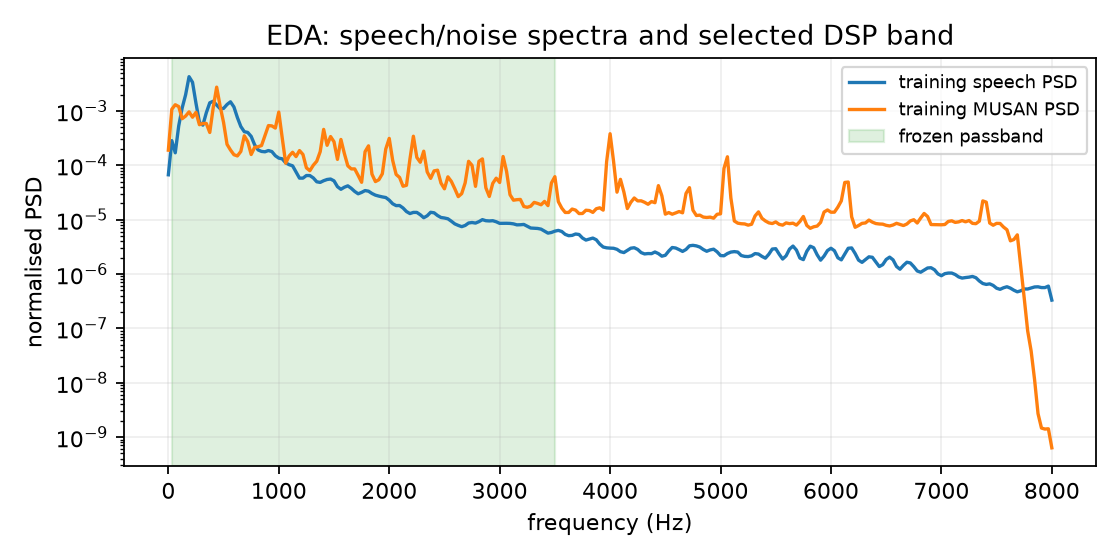

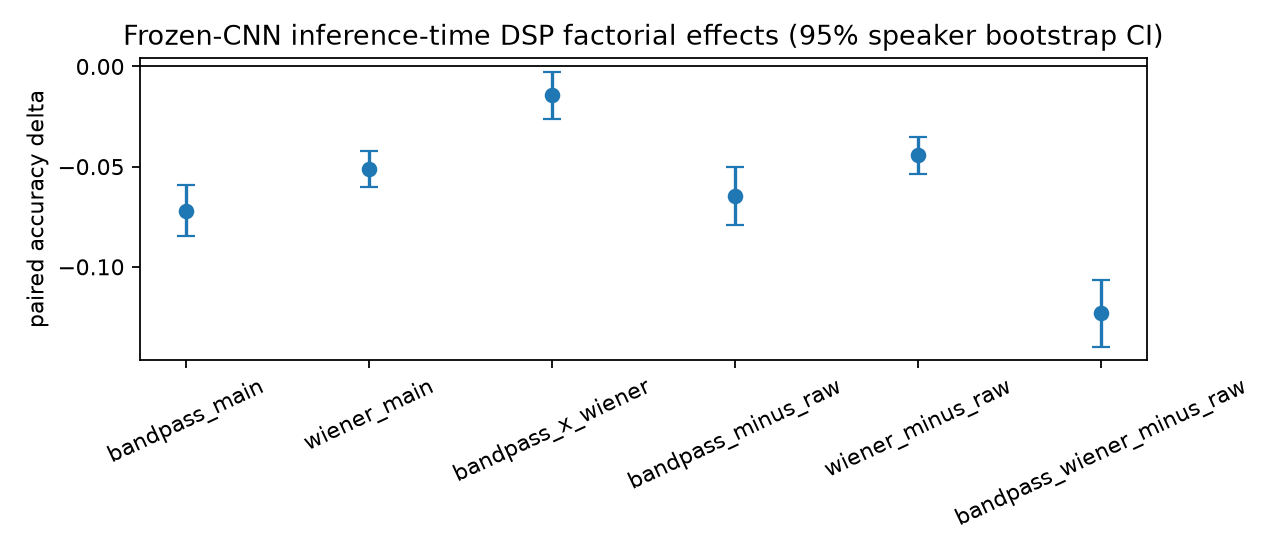

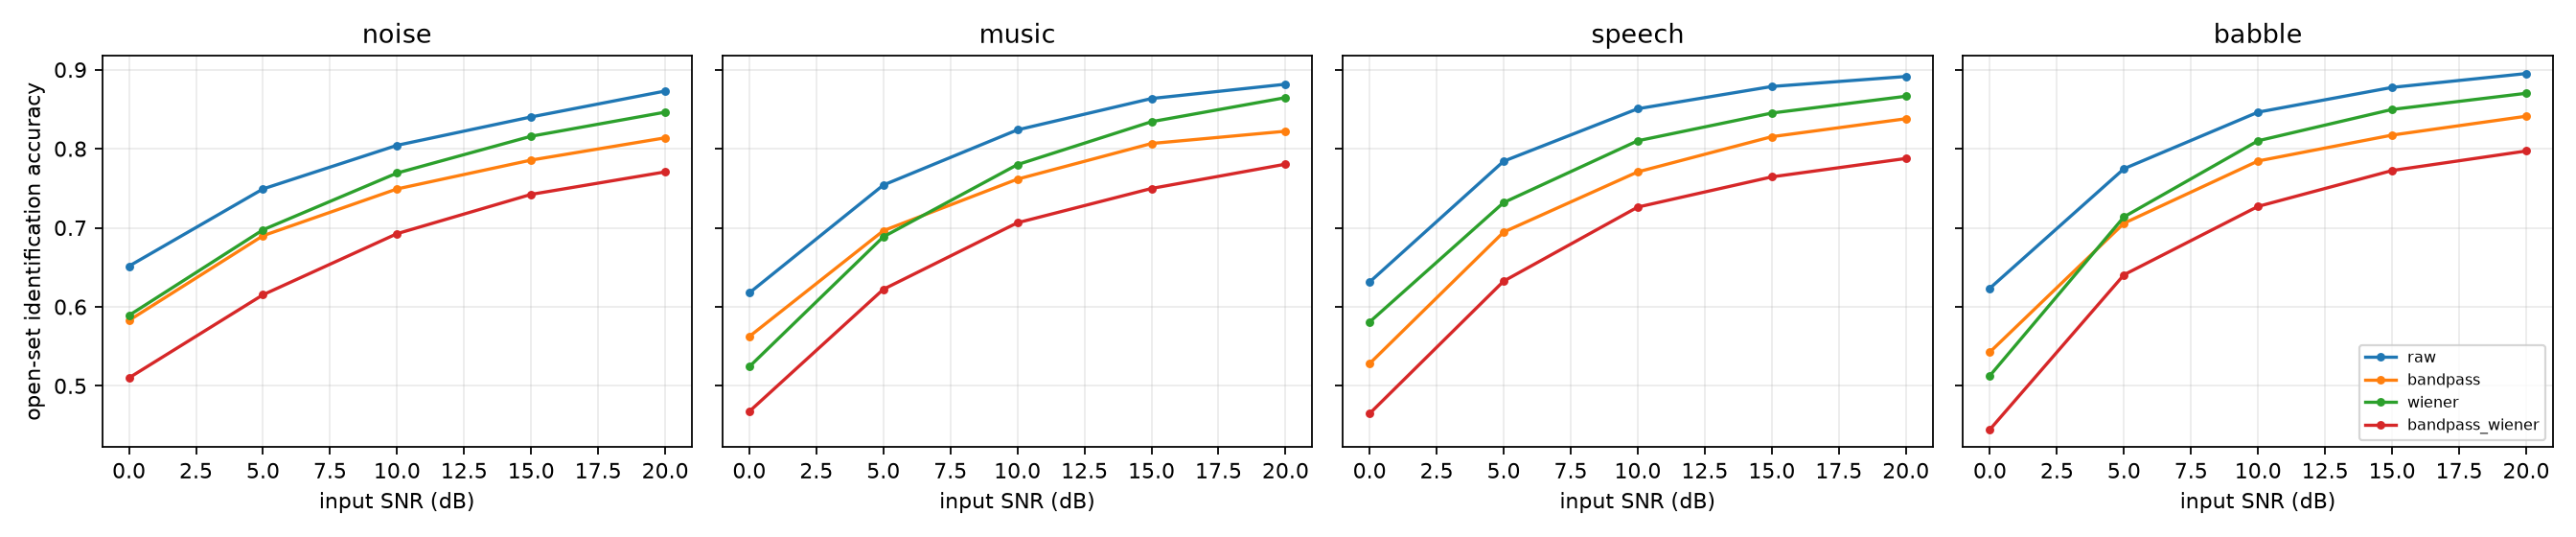

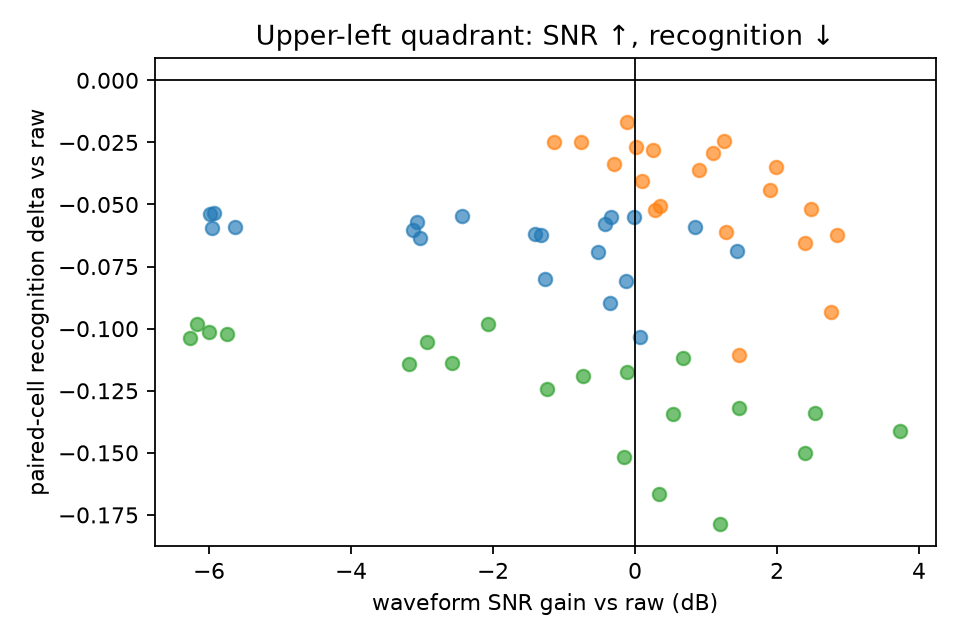

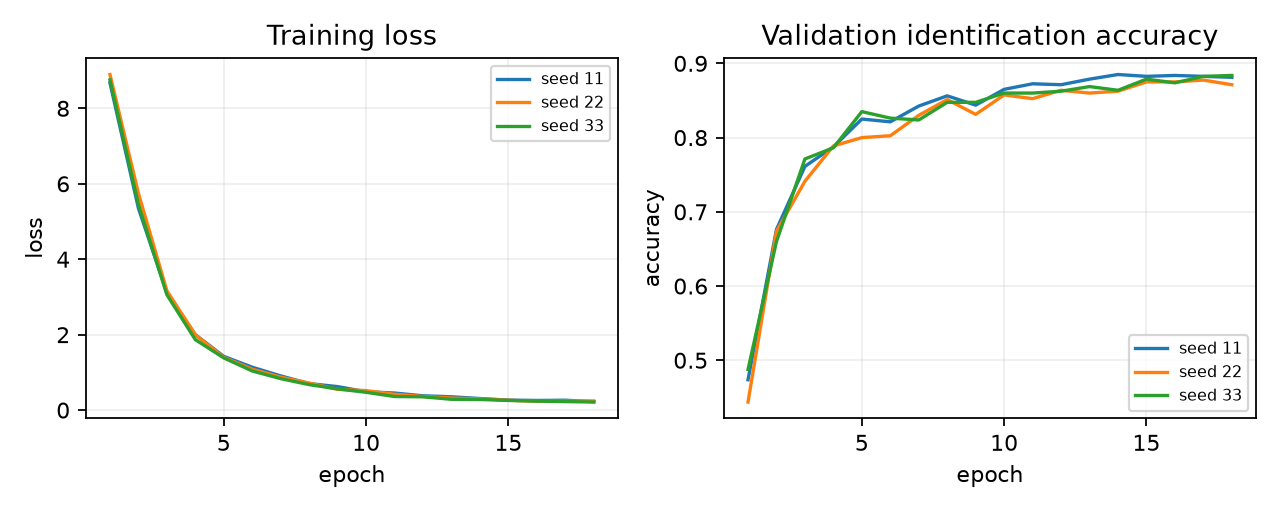

{'run_dir': 'outputs/dsp501-frozen-cnn-factorial/runs/run-1',
 'reports': 'outputs/dsp501-frozen-cnn-factorial/runs/run-1/reports'}

In [9]:
figures = execute_phase(context, 'figures', workers=WORKERS)
for path in figures.data['figures']:
    display(Image(filename=path))
display({'run_dir': str(config.run_dir), 'reports': str(config.report_root)})